# 5 · Hard-example mining with LanceDB

The worst slice is rare *foggy* frames. Generic training underfits them. Here we
fix it surgically: embed every frame, index the embeddings in **LanceDB**, use
vector search to gather the fog-like neighbourhood, and **up-weight** it during
training. This is the single biggest lever on the worst-group score.

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))   # make `harness` importable
import matplotlib
matplotlib.use("Agg")
import numpy as np
import matplotlib.pyplot as plt

from harness.data import make_synthetic_dataset, DatasetSpec, load_split, class_names

DATA = Path("../data/bdd-tiny.lance")
if not DATA.exists():
    print("building a small bdd-tiny ...")
    make_synthetic_dataset(DATA, DatasetSpec(n=3000, seed=7))
print("dataset:", DATA)

dataset: ../data/bdd-tiny.lance


### A brightness-invariant colour embedding

In [2]:
from harness.mining import embed
x, y, meta = load_split(DATA, "train")
feats = embed(x)
print("embedding shape:", feats.shape, "(R,G,B colour ratio + contrast)")

embedding shape: (2100, 4) (R,G,B colour ratio + contrast)


### Vector search: nearest neighbours of a fog frame are fog-like frames

In [3]:
from harness.mining import compute_sample_weights
from harness.config import load_config
cfg = load_config("base", {"mining": {"enabled": True, "strategy": "fog_knn", "boost": 6.0, "k": 8}})
w = compute_sample_weights(DATA, cfg)
print("rows up-weighted:", int((w > 1).sum()), "of", len(w))
print("fog frames in train:", int((meta['weather'] == 'foggy').sum()))
print("-> mining expanded the fog set via LanceDB neighbours")

rows up-weighted: 695 of 2100
fog frames in train: 196
-> mining expanded the fog set via LanceDB neighbours


### Before vs. after: train with and without fog mining

In [4]:
from harness.train import train
from harness.evaluator import evaluate
base = evaluate(train(load_config("base"), DATA), DATA)
mined = evaluate(train(cfg, DATA, sample_weights=w), DATA)
print(f"baseline : score={base['score']:.3f}  fog={base['per_weather']['foggy']:.3f}")
print(f"+mining  : score={mined['score']:.3f}  fog={mined['per_weather']['foggy']:.3f}")

baseline : score=0.883  fog=0.644
+mining  : score=0.975  fog=0.733


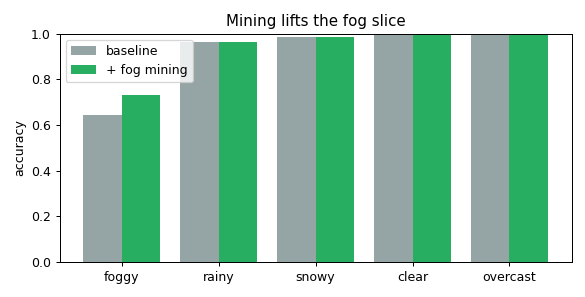

In [5]:
ws = sorted(base["per_weather"], key=base["per_weather"].get)
xpos = np.arange(len(ws)); fig, ax = plt.subplots(figsize=(6.5, 3.3))
ax.bar(xpos - 0.2, [base["per_weather"][k] for k in ws], 0.4, label="baseline", color="#95a5a6")
ax.bar(xpos + 0.2, [mined["per_weather"][k] for k in ws], 0.4, label="+ fog mining", color="#27ae60")
ax.set_xticks(xpos); ax.set_xticklabels(ws); ax.set_ylim(0, 1); ax.set_ylabel("accuracy")
ax.set_title("Mining lifts the fog slice"); ax.legend()
fig.tight_layout(); fig.savefig("fig_05_mining.png", dpi=90); plt.close(fig)
from IPython.display import Image; Image("fig_05_mining.png")

Mining moves the slice that matters. But be careful: over-boosting fog can starve
another slice and make *it* the new worst group — which is exactly the kind of
trade-off the keep/revert loop is built to catch (Chapter 6).